# Notebook 13 — Fourier Analysis: the frequency content of a brain rhythm

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to the **Fourier Analysis** lecture, and it continues from
Notebook 12. There, using only the **time** domain, we found a slow rhythm that appears when the
eyes close — but reading its speed off the autocorrelation was clumsy and we could not say *how
strong* it was. This week we switch to the **frequency** domain, where the Fourier transform
measures the strength of every frequency at once.

*Dataset:* the same EEG Alpha Waves recording as last week (alphawaves.npz)

### By the end of this notebook you will be able to:
- Build **synthetic signals** as sums of oscillations.
- Compute a signal's **amplitude** and **phase** spectra with the **FFT**, and say what each is for.
- Estimate a smooth power spectrum with **Welch's method**, on linear and log scales, and compute **band power**.
- **Filter** a signal (low-, high-, band-pass, notch) and know the pitfalls (phase, edges, filter ringing).
- Make a **spectrogram** and a **wavelet** time-frequency map, and read a **heatmap**, choosing a good **colormap**.

### Table of contents
1. [Loading the tools](#sec-1)
2. [A signal is a sum of oscillations](#sec-2)
3. [The Fourier transform](#sec-3)
4. [Amplitude and phase](#sec-4)
5. [Load the EEG](#sec-5)
6. [The spectrum of the EEG](#sec-6)
7. [A smoother spectrum: Welch](#sec-7)
8. [Band power](#sec-8)
9. [Filtering](#sec-9)
10. [Spectrogram and colormaps](#sec-10)
11. [Wavelets](#sec-11)

<a id="sec-1"></a>
## 1. Loading the tools
Same scientific stack as usual, plus signal-processing helpers from `scipy.signal`
(`welch`, `butter`, `filtfilt`, `iirnotch`, `spectrogram`), introduced as we use them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt, iirnotch, spectrogram
from cycler import cycler

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=["#1f77b4", "#ff7f0e", "#5b2c83"]),  # C0 blue, C1 orange, C2 purple
})

<a id="sec-2"></a>
## 2. A signal is a sum of oscillations
The idea behind Fourier analysis: **any signal can be built by adding simple sine waves of
different frequencies**. We start with signals we make ourselves, so we know exactly what is inside
them. Here is a 10 Hz wave plus a weaker 25 Hz wave.

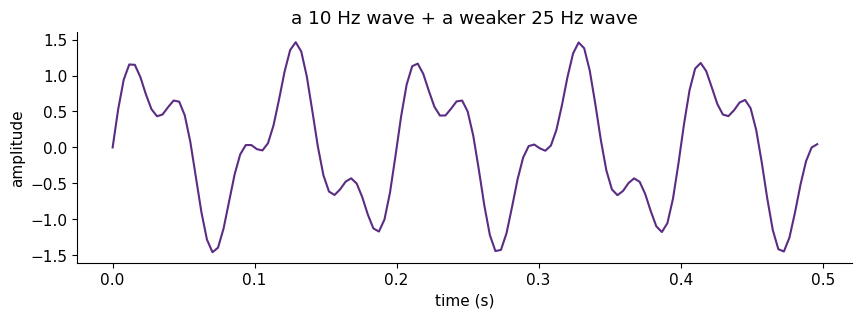

In [3]:
fs = 256                                # samples per second 
duration = 2                            # seconds
t = np.arange(0, duration, 1 / fs)      # time axis

signal = 1.0 * np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 25 * t)

fig, ax = plt.subplots(figsize=(10, 3))
show = int(0.5 * fs)                    # first half-second
ax.plot(t[:show], signal[:show], color="C2")
ax.set_xlabel("time (s)"); ax.set_ylabel("amplitude")
ax.set_title("a 10 Hz wave + a weaker 25 Hz wave")
plt.show()

<a id="sec-3"></a>
## 3. The Fourier transform (FFT)
The **Fourier transform** does the reverse: given a signal, it finds *which frequencies it is made
of and how much of each*. It is a **change of basis** — the same signal written in terms of sine
waves instead of time points (the linear-algebra idea from Notebooks 9–11). The **FFT** is the fast
algorithm that computes it. NumPy gives `np.fft.rfft(signal)` (one complex number per frequency) and
`np.fft.rfftfreq(len(signal), d=1/fs)` (the frequency each number belongs to). The **size** of each
number is the **amplitude** of that frequency.

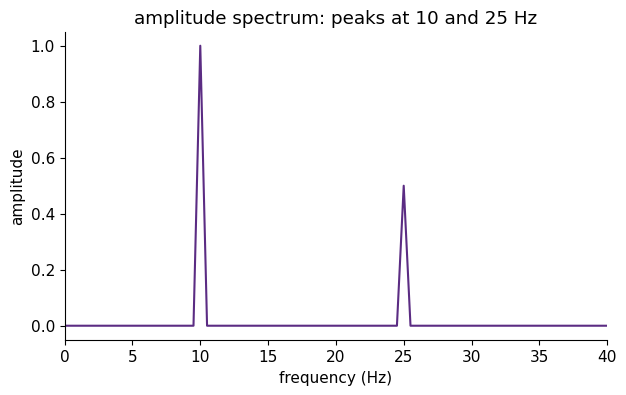

frequency resolution = 0.500 Hz  (= fs / number of samples)


In [4]:
spectrum   = np.fft.rfft(signal)
freqs      = np.fft.rfftfreq(len(signal), d=1 / fs)
amplitude  = np.abs(spectrum) / len(signal) * 2      # scale to real amplitude

fig, ax = plt.subplots()
ax.plot(freqs, amplitude, color="C2")
ax.set_xlim(0, 40)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("amplitude")
ax.set_title("amplitude spectrum: peaks at 10 and 25 Hz")
plt.show()

print(f"frequency resolution = {freqs[1] - freqs[0]:.3f} Hz  (= fs / number of samples)")

> **▶ Task 3.1 — Build and decompose your own signal.**
> Make a signal that is the sum of **three** sine waves — 4 Hz (amplitude 1), 10 Hz (amplitude 0.6)
> and 30 Hz (amplitude 0.3) — then compute and plot its amplitude spectrum. Do three peaks appear at
> the right frequencies, with the right relative heights?
>
> *Hints.* Reuse `t`. The amplitude spectrum is `np.abs(np.fft.rfft(signal)) / len(signal) * 2`, and
> the matching frequencies are `np.fft.rfftfreq(len(signal), d=1/fs)`.

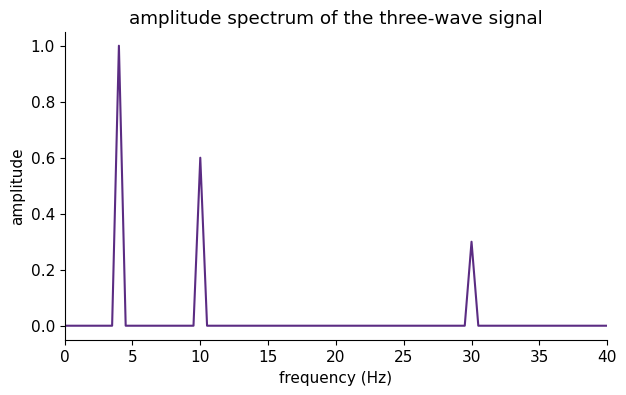

In [5]:
# TODO 3.1 — sum of three sines, then its amplitude spectrum
signal3 = (1.0 * np.sin(2 * np.pi * 4  * t)
           + 0.6 * np.sin(2 * np.pi * 10 * t)
           + 0.3 * np.sin(2 * np.pi * 30 * t))                    # TO BE REMOVED
freqs3 = np.fft.rfftfreq(len(signal3), d=1 / fs)                  # TO BE REMOVED
amp3   = np.abs(np.fft.rfft(signal3)) / len(signal3) * 2         # TO BE REMOVED

fig, ax = plt.subplots()
ax.plot(freqs3, amp3, color="C2")                                 # TO BE REMOVED
ax.set_xlim(0, 40); ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("amplitude")
ax.set_title("amplitude spectrum of the three-wave signal")
plt.show()

<a id="sec-4"></a>
## 4. Amplitude and phase
Each Fourier number is **complex**, carrying two things: its **size** (amplitude — *how much* of a
frequency) and its **angle** (**phase** — *where in its cycle* that wave starts). Phase matters
because two signals can have the **same amplitude spectrum** yet look completely different. Below,
both signals are the sum of the same five waves with the same amplitudes; in one the waves are all
**aligned** (each starts at its peak), in the other each starts at a **random** point of its cycle.
Watch how that changes the raw signal.

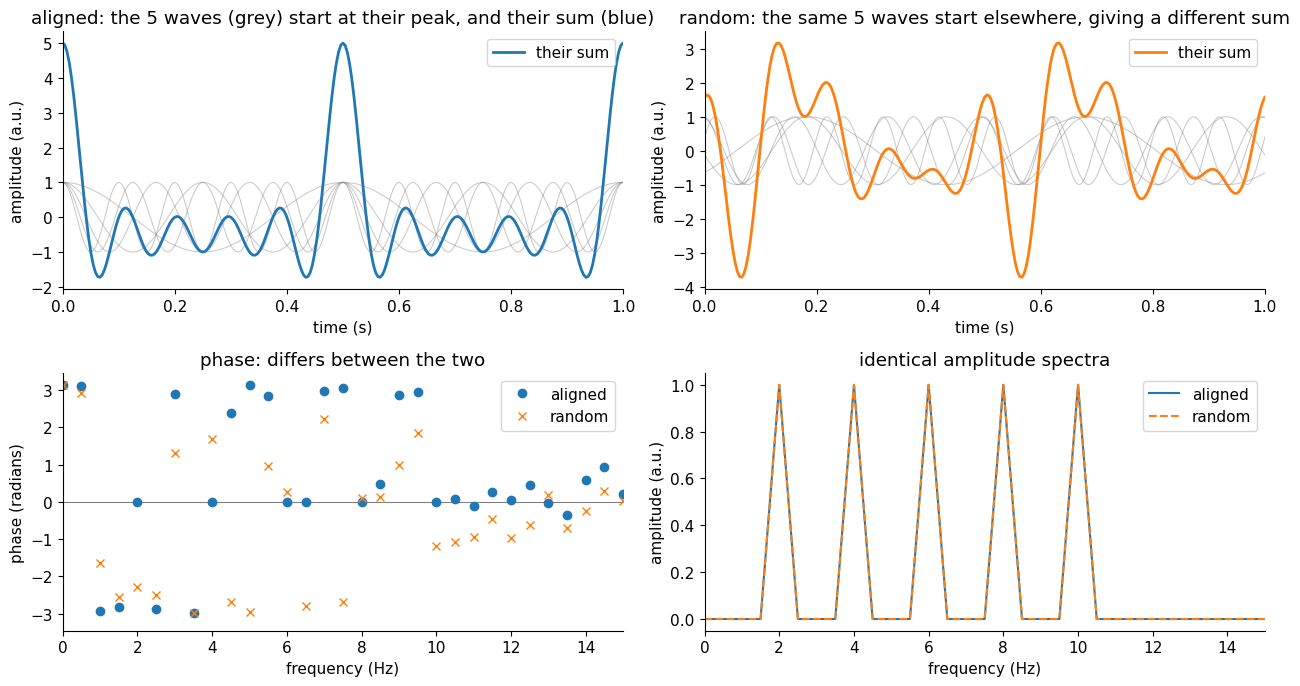

In [6]:
freqs_demo = [2, 4, 6, 8, 10]
rng = np.random.default_rng(0)
phases = [rng.uniform(0, 2 * np.pi) for _ in freqs_demo]   # a random starting phase per wave

signal_A = np.zeros_like(t)                # aligned: all phases 0
for f in freqs_demo:
    signal_A += np.cos(2 * np.pi * f * t)
signal_B = np.zeros_like(t)                # same waves, random phases
for f, ph in zip(freqs_demo, phases):
    signal_B += np.cos(2 * np.pi * f * t + ph)

# the FFT gives, at each frequency, an amplitude (how much) and a phase (where in its cycle)
fa      = np.fft.rfftfreq(len(t), d=1 / fs)
amp_A   = np.abs(np.fft.rfft(signal_A)) / len(t) * 2
amp_B   = np.abs(np.fft.rfft(signal_B)) / len(t) * 2
phase_A = np.angle(np.fft.rfft(signal_A))
phase_B = np.angle(np.fft.rfft(signal_B))

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# top-left: the five component waves (thin grey) and the signal they add up to (bold)
for f in freqs_demo:
    axes[0, 0].plot(t, np.cos(2 * np.pi * f * t), color="gray", alpha=0.4, lw=0.8)
axes[0, 0].plot(t, signal_A, color="C0", lw=2, label="their sum")
axes[0, 0].set_title("aligned: the 5 waves (grey) start at their peak, and their sum (blue)")
axes[0, 0].set_xlim(0, 1); axes[0, 0].set_xlabel("time (s)"); axes[0, 0].set_ylabel("amplitude (a.u.)"); axes[0, 0].legend()

# top-right: the same five waves but each shifted by a random phase, and their sum
for f, ph in zip(freqs_demo, phases):
    axes[0, 1].plot(t, np.cos(2 * np.pi * f * t + ph), color="gray", alpha=0.4, lw=0.8)
axes[0, 1].plot(t, signal_B, color="C1", lw=2, label="their sum")
axes[0, 1].set_title("random: the same 5 waves start elsewhere, giving a different sum")
axes[0, 1].set_xlim(0, 1); axes[0, 1].set_xlabel("time (s)"); axes[0, 1].set_ylabel("amplitude (a.u.)"); axes[0, 1].legend()

# bottom-left: the PHASE of each frequency — this is what differs between the two signals
axes[1, 0].axhline(0, color="grey", lw=0.8)
axes[1, 0].plot(fa, phase_A, color="C0", marker="o", ls="none", label="aligned")
axes[1, 0].plot(fa, phase_B, color="C1", marker="x", ls="none", label="random")
axes[1, 0].set_title("phase: differs between the two")
axes[1, 0].set_xlim(0, 15); axes[1, 0].set_xlabel("frequency (Hz)"); axes[1, 0].set_ylabel("phase (radians)"); axes[1, 0].legend()

# bottom-right: yet their amplitude spectra are identical
axes[1, 1].plot(fa, amp_A, color="C0", label="aligned")
axes[1, 1].plot(fa, amp_B, color="C1", ls="--", label="random")
axes[1, 1].set_title("identical amplitude spectra")
axes[1, 1].set_xlim(0, 15); axes[1, 1].set_xlabel("frequency (Hz)"); axes[1, 1].set_ylabel("amplitude (a.u.)"); axes[1, 1].legend()

plt.tight_layout(); plt.show()

So **amplitude tells you which rhythms are present; phase tells you how they line up** — the
shape and timing.

<a id="sec-5"></a>
## 5. Load the EEG, and gather each condition
The dataset now comes as a single compressed file, `alphawaves.npz`. We load it with `np.load`, pick one subject, and read the sampling rate
from the file. Because
the trials are stored separately, we **stitch them back into one continuous signal** (in block order)
for the time-frequency views later, and we also gather all the eyes-closed and all the eyes-open
trials into one signal each for the spectra, removing the mean as before.

In [22]:
# --- load the reformatted dataset (a single .npz file) ---
DATA_DIR = "/Users/vidalbe/Downloads/Datasets_and_exploratory_notebooks/"      # <-- folder containing alphawaves.npz
SUBJECT  = 17                            # choose a subject from 0 to 19

archive = np.load(f"{DATA_DIR}/alphawaves.npz")
X         = archive["X"]                       # (trials, channels, samples)
ch_names  = [str(c) for c in archive["ch_names"]]
condition = archive["condition"]               # "eyes_closed" / "eyes_open" per trial
subject   = archive["subject"]
sampling_rate = float(archive["sfreq"])        # read it from the file (256 Hz here)

# keep this subject's trials, put them in block (chronological) order
this_subject = subject == f"subject_{SUBJECT:02d}"
X_sub    = X[this_subject]
cond_sub = condition[this_subject]
order    = np.argsort(archive["block"][this_subject])
X_sub, cond_sub = X_sub[order], cond_sub[order]

# the data is already cut into trials, so we pick a channel (O1) and stitch the trials
# back into one continuous signal (in block order) for the time-frequency views later
o1_index = ch_names.index("O1")
trials   = X_sub[:, o1_index, :]               # (n_trials, samples) for O1
o1       = trials.reshape(-1)                   # one long signal
time     = np.arange(len(o1)) / sampling_rate

trial_len     = X.shape[2]                      # 2560 samples = 10 s per trial
pad           = int(0.5 * sampling_rate)        # skip 0.5 s at each trial edge
block         = int(9 * sampling_rate)          # use 9 s of each 10 s trial
trial_starts  = np.arange(len(X_sub)) * trial_len
closed_starts = trial_starts[cond_sub == "eyes_closed"]
open_starts   = trial_starts[cond_sub == "eyes_open"]

# gather all the eyes-closed data and all the eyes-open data (mean removed, as before)
closed = trials[cond_sub == "eyes_closed"].reshape(-1)
open_  = trials[cond_sub == "eyes_open"].reshape(-1)
closed = closed - closed.mean()
open_  = open_  - open_.mean()
print(f"sampling rate = {sampling_rate:.0f} Hz | eyes-closed data: {len(closed)/sampling_rate:.0f} s")

sampling rate = 256 Hz | eyes-closed data: 50 s


<a id="sec-6"></a>
## 6. The spectrum of the real EEG — linear vs log
We take the FFT of all the eyes-closed and eyes-open data. By default `ax.plot` uses a **linear**
y-axis (equal spacing for equal amounts), which makes the tall alpha peak obvious but hides
everything small. Switching the y-axis to **logarithmic** — with `ax.set_yscale("log")` — lets us
see the weak fast activity and the 50 Hz mains spike too. We plot both, side by side.

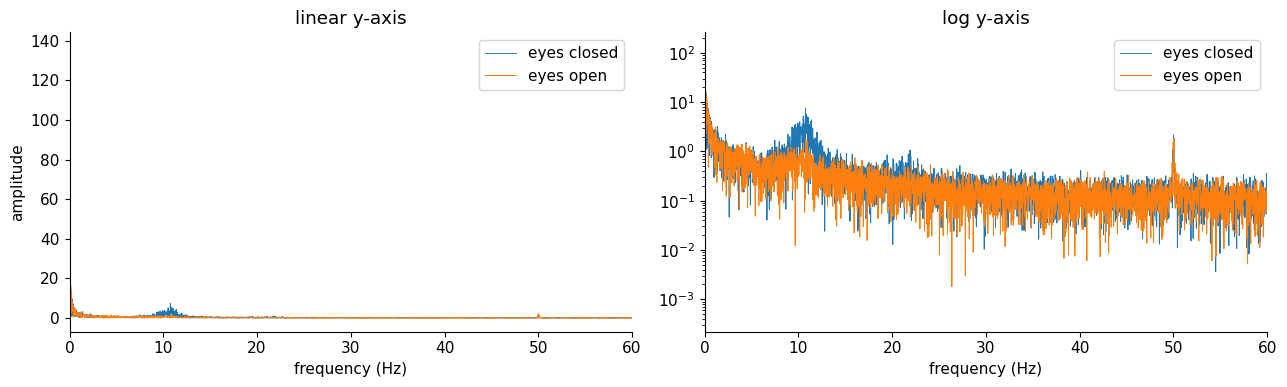

In [23]:
freqs_c = np.fft.rfftfreq(len(closed), d=1 / sampling_rate)
freqs_o = np.fft.rfftfreq(len(open_),  d=1 / sampling_rate)
amp_closed = np.abs(np.fft.rfft(closed)) / len(closed) * 2
amp_open   = np.abs(np.fft.rfft(open_))  / len(open_)  * 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax_i in axes:
    ax_i.plot(freqs_c, amp_closed, color="C0", label="eyes closed", lw=0.7)
    ax_i.plot(freqs_o, amp_open,   color="C1", label="eyes open",   lw=0.7)
    ax_i.set_xlim(0, 60); ax_i.set_xlabel("frequency (Hz)"); ax_i.legend()
axes[0].set_ylabel("amplitude"); axes[0].set_title("linear y-axis")
axes[1].set_yscale("log");       axes[1].set_title("log y-axis")
plt.tight_layout(); plt.show()

> **❓ Q6.1.** On the linear plot, which single feature stands out? On the log plot, what extra
> features become visible (the 1/f background, the small fast activity, and the 50 Hz spike)? The
> alpha bump is present with eyes closed and much smaller with eyes open.
>
> A note on axis limits. The scale (linear vs log) is only half the story — the limits matter too, and matplotlib does not always choose them well. You may set limits yourself with ax.set_ylim(bottom, top) and ax.set_xlim(left, right) (each argument is optional, e.g. ax.set_ylim(bottom=0.01) fixes only the lower edge).

<a id="sec-7"></a>
## 7. A smoother spectrum: Welch's method
The single FFT above is jagged because it uses the whole signal at once. **Welch's method** cuts the
signal into overlapping windows, takes each window's spectrum, and **averages** them — trading a
little frequency resolution for a much smoother **power spectral density (PSD)**. (Multitaper
methods, from the lecture, refine the same averaging idea.) Again we show it on both scales.

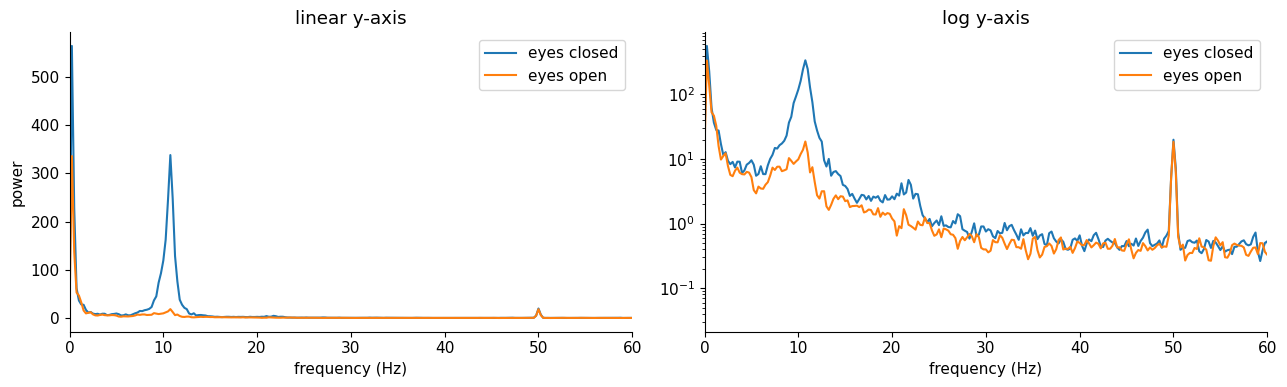

In [11]:
f_closed, psd_closed = welch(closed, fs=sampling_rate, nperseg=1024)
f_open,   psd_open   = welch(open_,  fs=sampling_rate, nperseg=1024)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax_i in axes:
    ax_i.plot(f_closed, psd_closed, color="C0", label="eyes closed")
    ax_i.plot(f_open,   psd_open,   color="C1", label="eyes open")
    ax_i.set_xlim(0, 60); ax_i.set_xlabel("frequency (Hz)"); ax_i.legend()
axes[0].set_ylabel("power"); axes[0].set_title("linear y-axis")
axes[1].set_yscale("log");   axes[1].set_title("log y-axis")
plt.tight_layout(); plt.show()

> **▶ Task 7.1 — This subject's alpha peak frequency.**
> Everyone's alpha sits at a slightly different frequency. Find the frequency of **maximum power
> between 7 and 13 Hz** in the eyes-closed PSD and print it. *Hint:* build a boolean mask on
> `f_closed`, then use `np.argmax` on `psd_closed` inside it.

In [24]:
# TODO 7.1 — the alpha peak frequency (eyes closed)
band = (f_closed >= 7) & (f_closed <= 13)                 # TO BE REMOVED
peak = f_closed[band][np.argmax(psd_closed[band])]        # TO BE REMOVED
print(f"alpha peak frequency = {peak:.1f} Hz")            # TO BE REMOVED

alpha peak frequency = 10.8 Hz


<a id="sec-8"></a>
## 8. Band power
Neuroscientists group frequencies into **bands** (delta 1–4, theta 4–8, **alpha 8–12**, beta 13–30,
gamma 30+ Hz). The **power in a band** is the area under the PSD between two frequencies —
`np.trapezoid` computes it. This is the number we lacked last week: *how much* alpha there is.

In [25]:
def band_power(freqs, psd, low, high):
    # area under the PSD between `low` and `high` Hz
    mask = (freqs >= low) & (freqs <= high)
    return np.trapezoid(psd[mask], freqs[mask])

alpha_closed = band_power(f_closed, psd_closed, 8, 12)
alpha_open   = band_power(f_open,   psd_open,   8, 12)
print(f"alpha power (8-12 Hz)  closed = {alpha_closed:.1f}, open = {alpha_open:.1f}")
print(f"ratio closed / open = {alpha_closed / alpha_open:.1f}")

alpha power (8-12 Hz)  closed = 420.9, open = 36.9
ratio closed / open = 11.4


> **▶ Task 8.1 — Compare two bands.**
> Using `band_power`, compute the **beta** band power (13–30 Hz) for both conditions and print the
> closed / open ratio. Is the eyes-closed increase as striking for beta as for alpha?

In [14]:
# TODO 8.1 — beta band power (13-30 Hz), both conditions
beta_closed = band_power(f_closed, psd_closed, 13, 30)   # TO BE REMOVED
beta_open   = band_power(f_open,   psd_open,   13, 30)   # TO BE REMOVED
print(f"beta ratio closed / open = {beta_closed / beta_open:.1f}")   # TO BE REMOVED

beta ratio closed / open = 2.0


<a id="sec-9"></a>
## 9. Filtering: keep the frequencies you want
A **filter** removes some frequencies and keeps others: **low-pass** keeps slow, **high-pass** keeps
fast, **band-pass** keeps a range, **notch** removes one narrow frequency. We build them with
`butter` (or `iirnotch`) and apply them with `filtfilt`, which runs the filter forwards then
backwards so it adds **no phase shift**. Two cautions from the lecture: a one-way filter would
*distort the phase*, and every filter gives unreliable values at the signal's **edges**.

First a **notch** at 50 Hz. We plot the whole spectrum on a log axis so we can check that the low
frequencies are **untouched** and only the 50 Hz spike is gone.

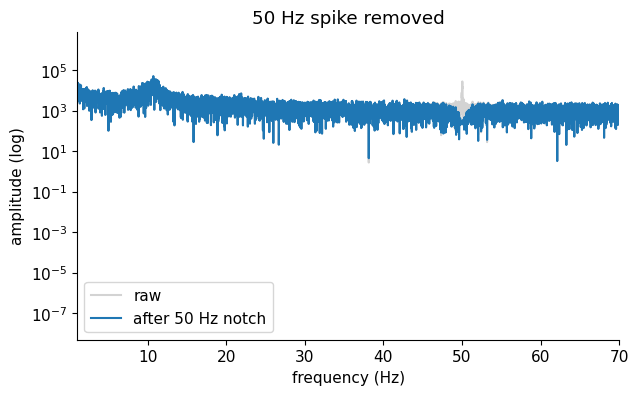

In [15]:
b_n, a_n = iirnotch(50, Q=30, fs=sampling_rate)
o1_notched = filtfilt(b_n, a_n, o1)

ff = np.fft.rfftfreq(len(o1), d=1 / sampling_rate)
amp_raw   = np.abs(np.fft.rfft(o1 - o1.mean()))
amp_notch = np.abs(np.fft.rfft(o1_notched - o1_notched.mean()))

fig, ax = plt.subplots()
ax.plot(ff, amp_raw,   color="lightgray", label="raw")
ax.plot(ff, amp_notch, color="C0", label="after 50 Hz notch")
ax.set_yscale("log"); ax.set_xlim(1, 70)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("amplitude (log)")
ax.set_title("50 Hz spike removed"); ax.legend()
plt.show()

Now a **band-pass** to isolate the alpha rhythm, shown for eyes closed *and* eyes open.

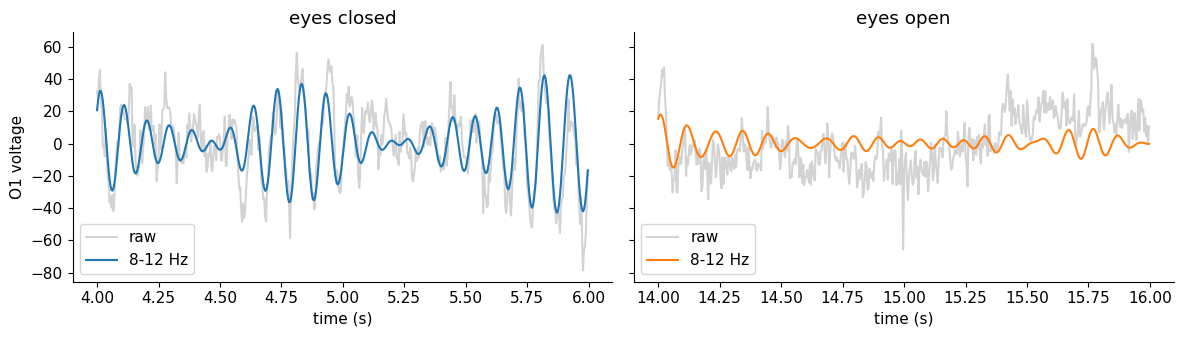

In [16]:
b, a = butter(4, [8, 12], btype="band", fs=sampling_rate)
o1_alpha = filtfilt(b, a, o1)

seg_c = slice(closed_starts[0] + int(4 * sampling_rate), closed_starts[0] + int(6 * sampling_rate))
seg_o = slice(open_starts[0]   + int(4 * sampling_rate), open_starts[0]   + int(6 * sampling_rate))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].plot(time[seg_c], o1[seg_c] - o1[seg_c].mean(), color="lightgray", label="raw")
axes[0].plot(time[seg_c], o1_alpha[seg_c], color="C0", label="8-12 Hz")
axes[0].set_title("eyes closed"); axes[0].legend(); axes[0].set_xlabel("time (s)")
axes[1].plot(time[seg_o], o1[seg_o] - o1[seg_o].mean(), color="lightgray", label="raw")
axes[1].plot(time[seg_o], o1_alpha[seg_o], color="C1", label="8-12 Hz")
axes[1].set_title("eyes open"); axes[1].legend(); axes[1].set_xlabel("time (s)")
axes[0].set_ylabel("O1 voltage")
plt.tight_layout(); plt.show()

Notice the eyes-open trace is not flat — it still shows a small ~10 Hz wiggle. That is a
warning about **preprocessing**: a band-pass filter always outputs something oscillating near its
centre frequency, even when fed almost pure noise. Be aware that a narrow band-passed trace *looking* rhythmic does
not prove a rhythm is really there.

> **▶ Task 9.1 — A low-pass filter.**
> Build a **low-pass** filter that keeps everything below 30 Hz, apply it to `o1`, and plot a
> 2-second eyes-closed segment (raw vs filtered): the mains buzz should vanish while the slow rhythm
> stays. *Hint:* `butter(4, 30, btype="low", fs=sampling_rate)` returns `b, a`; apply with
> `filtfilt`.

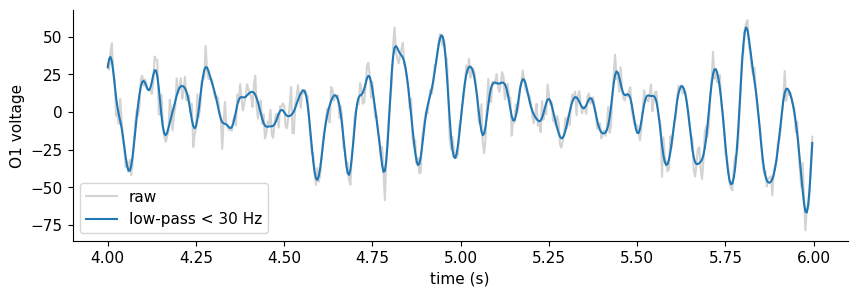

In [17]:
# TODO 9.1 — low-pass below 30 Hz
b_lp, a_lp = butter(4, 30, btype="low", fs=sampling_rate)   # TO BE REMOVED
o1_low = filtfilt(b_lp, a_lp, o1)                            # TO BE REMOVED

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time[seg_c], o1[seg_c] - o1[seg_c].mean(), color="lightgray", label="raw")
ax.plot(time[seg_c], o1_low[seg_c] - o1_low[seg_c].mean(), color="C0", label="low-pass < 30 Hz")  # TO BE REMOVED
ax.set_xlabel("time (s)"); ax.set_ylabel("O1 voltage"); ax.legend()
plt.show()

<a id="sec-10"></a>
## 10. Spectrogram, and choosing a colormap
A single spectrum assumes the frequencies are steady, but the alpha rhythm switches *on and off*. A
**spectrogram** shows the spectrum **over time**: it slides a window along the signal, takes the
spectrum in each window, and stacks them into a **heatmap** (frequency up, time across, power as
colour). The **colorbar** tells us what the colours mean.

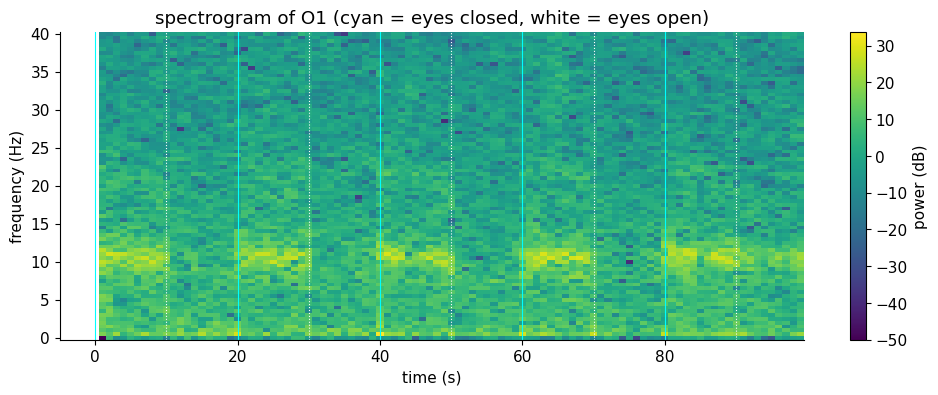

In [26]:
# spectrogram() returns three things: the frequencies, the time points of each window,
# and the power at every (frequency, time) — a 2-D grid we will draw as a heatmap.
frequencies, window_times, power = spectrogram(o1, fs=sampling_rate, nperseg=512, noverlap=256)

# keep only frequencies up to 40 Hz
low_enough = frequencies <= 40
frequencies = frequencies[low_enough]
power = power[low_enough]

# EEG power spans a huge range, so we view it on a decibel (log) scale, exactly like the
# log y-axis we used for the spectra. (The tiny + 1e-12 just avoids log of zero.)
power_dB = 10 * np.log10(power + 1e-12)

fig, ax = plt.subplots(figsize=(12, 4))
heatmap = ax.pcolormesh(window_times, frequencies, power_dB, cmap="viridis")
fig.colorbar(heatmap, ax=ax, label="power (dB)")

# mark the cues, as before
for s in closed_starts:
    ax.axvline(time[s], color="cyan", lw=0.8)
for s in open_starts:
    ax.axvline(time[s], color="white", lw=0.8, linestyle=":")

ax.set_xlabel("time (s)"); ax.set_ylabel("frequency (Hz)")
ax.set_title("spectrogram of O1 (cyan = eyes closed, white = eyes open)")
plt.show()

The **colormap** is not just decoration. A good map is *perceptually uniform* — equal steps in
the data look like equal steps in colour — so the picture is faithful; `viridis`, `magma` and
`cividis` are like this, and are also **colourblind-friendly**. Rainbow maps such as `jet` are still
common but can **mislead**: their bright yellow/cyan bands look like edges in the data that are
really just artefacts of the colours, and they are hard to read for colourblind viewers. Rule of
thumb: prefer a perceptually-uniform, colourblind-friendly map.

> **▶ Task 10.1 — The same picture, two colormaps.**
> Redraw the spectrogram twice, side by side: once with `cmap="cividis"` (perceptually uniform,
> colourblind-friendly) and once with `cmap="jet"` (rainbow). Do the false bands in `jet` tempt you
> to see features that the `cividis` version does not show? *Hint:* reuse `t_s`, `f_s`, `keep` and
> `Sxx` from the cell above.

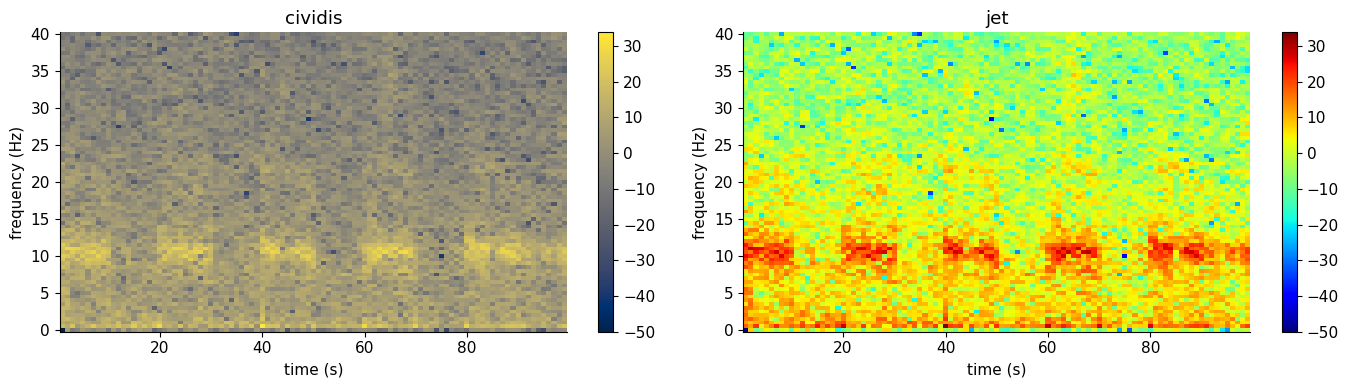

In [19]:
# TODO 10.1 — compare two colormaps on the same spectrogram
# (reuse window_times, frequencies and power_dB from the spectrogram cell above)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax_i, cmap in zip(axes, ["cividis", "jet"]):                                # TO BE REMOVED
    heatmap = ax_i.pcolormesh(window_times, frequencies, power_dB, cmap=cmap)   # TO BE REMOVED
    fig.colorbar(heatmap, ax=ax_i)                                              # TO BE REMOVED
    ax_i.set_title(cmap)                                                        # TO BE REMOVED
    ax_i.set_xlabel("time (s)"); ax_i.set_ylabel("frequency (Hz)")              # TO BE REMOVED
plt.tight_layout(); plt.show()

<a id="sec-11"></a>
## 11. Wavelets: a time-frequency view with an adaptive window
A spectrogram uses **one fixed window length for every frequency**, so its resolution is the same
everywhere. A **wavelet transform** uses a window that **scales with frequency**: short for fast
oscillations (good timing), long for slow ones (good frequency precision). It slides a little burst
of oscillation — a **Morlet wavelet** — of each frequency along the signal. `scipy` no longer ships
a wavelet routine, so we build the wavelets ourselves.

We draw the wavelet map and the spectrogram one above the other, on the same colour scale, so you
can compare them directly.

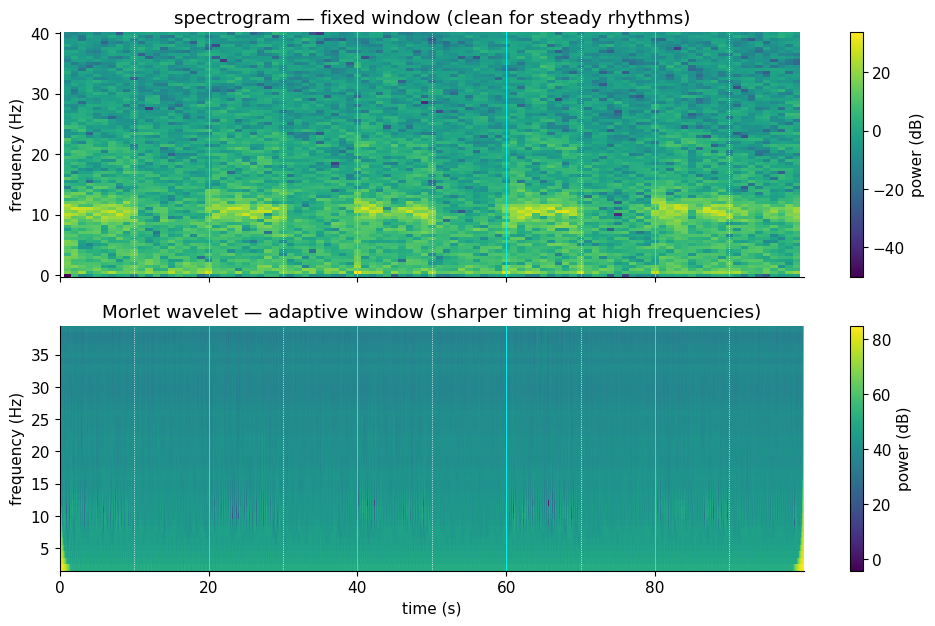

In [20]:
def morlet_power(signal, freqs, fs, n_cycles=7):
    # For each frequency we build a small "Morlet wavelet" — a short burst of oscillation
    # windowed by a bell curve — slide it along the signal, and read off how strongly the
    # signal matches that frequency at each moment.
    power = np.zeros((len(freqs), len(signal)))          # one row per frequency, one column per time point

    for i, f in enumerate(freqs):
        # 1) how long the wavelet lasts: we ask for n_cycles cycles of frequency f,
        #    so slow frequencies get a long wavelet and fast ones a short wavelet.
        width = n_cycles / (2 * np.pi * f)               # duration of the wavelet, in seconds

        # 2) a little time axis for the wavelet, a few widths on each side of zero
        wavelet_time = np.arange(-3 * width, 3 * width, 1 / fs)

        # 3) the wavelet itself = an oscillation at frequency f  ×  a bell-shaped (Gaussian) window
        oscillation = np.exp(2j * np.pi * f * wavelet_time)          # a complex wave at f Hz
        bell        = np.exp(-wavelet_time ** 2 / (2 * width ** 2))  # Gaussian that fades the ends out
        wavelet     = oscillation * bell
        wavelet     = wavelet / np.sqrt(np.sum(np.abs(wavelet) ** 2))  # normalise so frequencies are comparable

        # 4) slide the wavelet along the signal (a convolution); the size of the result,
        #    squared, is the power at this frequency across time.
        power[i] = np.abs(np.convolve(signal, wavelet, mode="same")) ** 2

    return power


wavelet_frequencies = np.arange(2, 40, 1)               # the frequencies we scan
wavelet_power = morlet_power(o1, wavelet_frequencies, sampling_rate)
wavelet_power_dB = 10 * np.log10(wavelet_power + 1e-12)  # decibel scale, as for the spectrogram

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# top: the spectrogram from before — its own colour scale
top = axes[0].pcolormesh(window_times, frequencies, power_dB, cmap="viridis")
fig.colorbar(top, ax=axes[0], label="power (dB)")
axes[0].set_title("spectrogram — fixed window (clean for steady rhythms)")
axes[0].set_ylabel("frequency (Hz)")

# bottom: the wavelet map — its own, separate colour scale (the values live in a different range)
bottom = axes[1].pcolormesh(time, wavelet_frequencies, wavelet_power_dB, cmap="viridis")
fig.colorbar(bottom, ax=axes[1], label="power (dB)")
axes[1].set_title("Morlet wavelet — adaptive window (sharper timing at high frequencies)")
axes[1].set_ylabel("frequency (Hz)"); axes[1].set_xlabel("time (s)")

for a in axes:
    for s in closed_starts:
        a.axvline(time[s], color="cyan", lw=0.6)
    for s in open_starts:
        a.axvline(time[s], color="white", lw=0.6, linestyle=":")

plt.show()

On our alpha data the spectrogram actually looked cleaner — because alpha is a steady, sustained rhythm, which is exactly the spectrogram's strong suit. The wavelet earns its keep when a signal has **brief, fast events** whose timing matters. Let's design such a signal ourselves — a steady slow rhythm plus three short high-frequency bursts — and look at it both ways.

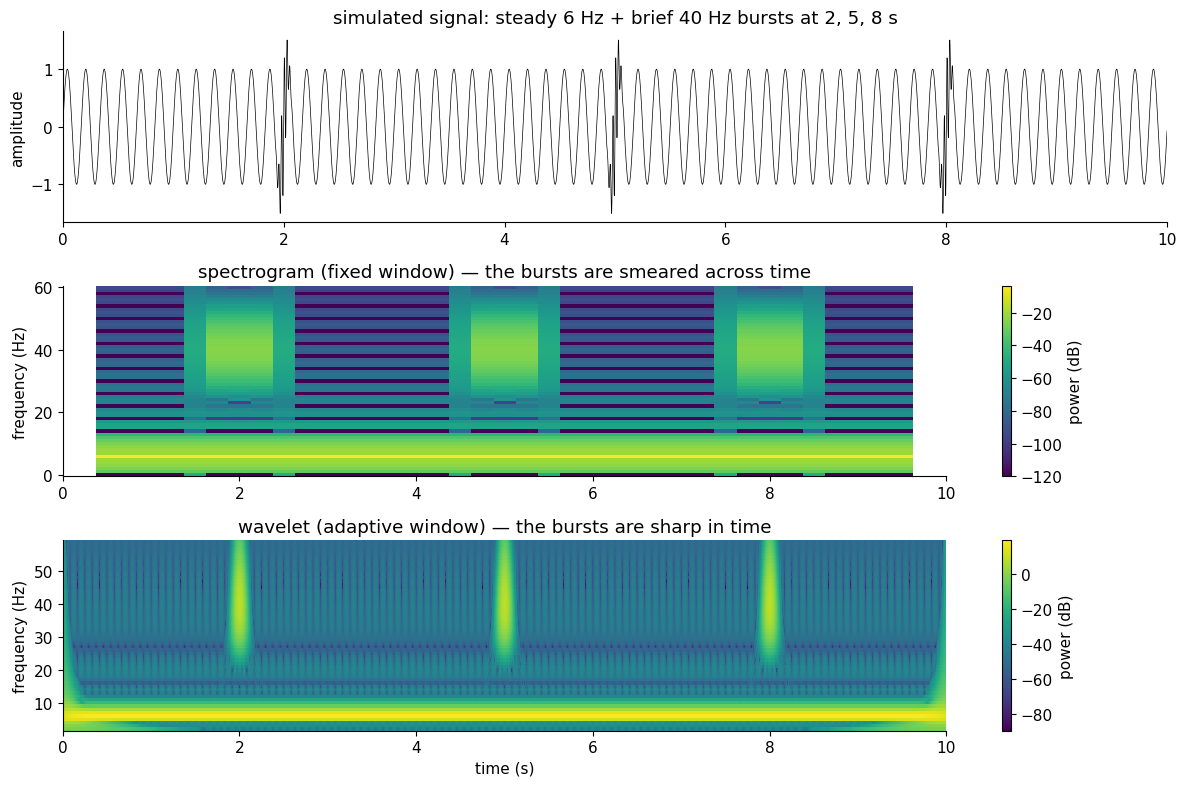

In [21]:
# a signal we design ourselves: a steady 6 Hz rhythm plus three brief 40 Hz bursts
fs = 512
t_sim = np.arange(0, 10, 1 / fs)
sim = np.sin(2 * np.pi * 6 * t_sim)                        # steady slow rhythm, all the way through
for onset in [2, 5, 8]:                                    # add three short high-frequency bursts
    brief_window = np.exp(-((t_sim - onset) ** 2) / (2 * 0.03 ** 2))   # a ~80 ms bell around `onset`
    sim += brief_window * np.sin(2 * np.pi * 40 * t_sim)   # a 40 Hz burst, only while the bell is open

# describe the same signal two ways
sim_freqs, sim_times, sim_power = spectrogram(sim, fs=fs, nperseg=512, noverlap=384)
sim_low = sim_freqs <= 60
sim_spectrogram_dB = 10 * np.log10(sim_power[sim_low] + 1e-12)

sim_wavelet_freqs = np.arange(2, 60, 1)
sim_wavelet_dB = 10 * np.log10(morlet_power(sim, sim_wavelet_freqs, fs) + 1e-12)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(t_sim, sim, color="black", lw=0.5)
axes[0].set_title("simulated signal: steady 6 Hz + brief 40 Hz bursts at 2, 5, 8 s")
axes[0].set_xlim(0, 10); axes[0].set_ylabel("amplitude")

top = axes[1].pcolormesh(sim_times, sim_freqs[sim_low], sim_spectrogram_dB, cmap="viridis")
fig.colorbar(top, ax=axes[1], label="power (dB)")
axes[1].set_title("spectrogram (fixed window) — the bursts are smeared across time")
axes[1].set_ylabel("frequency (Hz)")

bottom = axes[2].pcolormesh(t_sim, sim_wavelet_freqs, sim_wavelet_dB, cmap="viridis")
fig.colorbar(bottom, ax=axes[2], label="power (dB)")
axes[2].set_title("wavelet (adaptive window) — the bursts are sharp in time")
axes[2].set_ylabel("frequency (Hz)"); axes[2].set_xlabel("time (s)")

for a in axes[1:]:
    a.set_xlim(0, 10)
plt.tight_layout(); plt.show()

So neither is "better" — they make different trade-offs. The **spectrogram** treats every
frequency the same, so it looks clean and blocky and is ideal for a **sustained** rhythm like our
alpha. The **wavelet** gives sharp timing for fast, brief events (short window up high) and sharp
frequency for slow ones (long window down low), so it is the tool of choice when the **precise
timing of short bursts** matters across a wide frequency range — common in EEG for evoked responses
and cross-frequency analyses. For simply asking "is alpha on or off right now", the spectrogram is
usually enough.

## What we found
Over two weeks we went from **time** to **frequency**. The Fourier transform *measured* the rhythm
the autocorrelation had only hinted at — a clear alpha peak, strong with the eyes closed and weak
with them open. Welch's method gave a reliable spectrum and a single **band-power** number;
**filtering** isolated the alpha rhythm and removed the 50 Hz mains noise (while reminding us a
filter can manufacture an oscillation, so we check the power); and the **spectrogram** and
**wavelet** maps showed the rhythm switching on and off in time. These are the everyday tools of
EEG, MEG and LFP analysis.